In [2]:
import os
import pandas as pd

# This looks for ANY file ending in .csv
found_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            found_path = os.path.join(dirname, filename)
            print(f"I found a file! Loading: {found_path}")
            break # Stop looking once we find one

# Safety check: only try to read if we actually found something
if found_path:
    df = pd.read_csv(found_path)
    print("Success! Data loaded into 'df'.")
    print(df.head())
else:
    print("I couldn't find any CSV files. Did you add the dataset to the notebook?")

I found a file! Loading: /kaggle/input/notebooks/minhtonng/fake-news-liar-dataset/liar_dataset/train_pos.csv
Success! Data loaded into 'df'.
   index  $  ''  (  )  ,  --  .  :  CC  ...  VBG  VBN  VBP  VBZ  WDT  WP  WP$  \
0      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    2    0   0    0   
1      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    0    0   0    0   
2      0  0   0  0  0  0   0  0  0   0  ...    1    0    0    1    0   0    0   
3      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    1    0   0    0   
4      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    0    0   0    0   

   WRB  ``        label  
0    0   0        false  
1    2   0    half-true  
2    0   0  mostly-true  
3    0   0        false  
4    0   0    half-true  

[5 rows x 47 columns]


In [3]:
# 1. Print top rows to see the data 
print("--- Top 5 Rows ---")
print(df.head())

# 2. Check the "Stats" 
print("\n--- Summary Statistics ---")
print(df.describe(include='all'))

# 3. Check for missing values 
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Top 5 Rows ---
   index  $  ''  (  )  ,  --  .  :  CC  ...  VBG  VBN  VBP  VBZ  WDT  WP  WP$  \
0      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    2    0   0    0   
1      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    0    0   0    0   
2      0  0   0  0  0  0   0  0  0   0  ...    1    0    0    1    0   0    0   
3      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    1    0   0    0   
4      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    0    0   0    0   

   WRB  ``        label  
0    0   0        false  
1    2   0    half-true  
2    0   0  mostly-true  
3    0   0        false  
4    0   0    half-true  

[5 rows x 47 columns]

--- Summary Statistics ---
          index             $       ''        (        )        ,       --  \
count   10240.0  10240.000000  10240.0  10240.0  10240.0  10240.0  10240.0   
unique      NaN           NaN      NaN      NaN      NaN      NaN      NaN   
top         NaN           NaN      NaN      NaN      

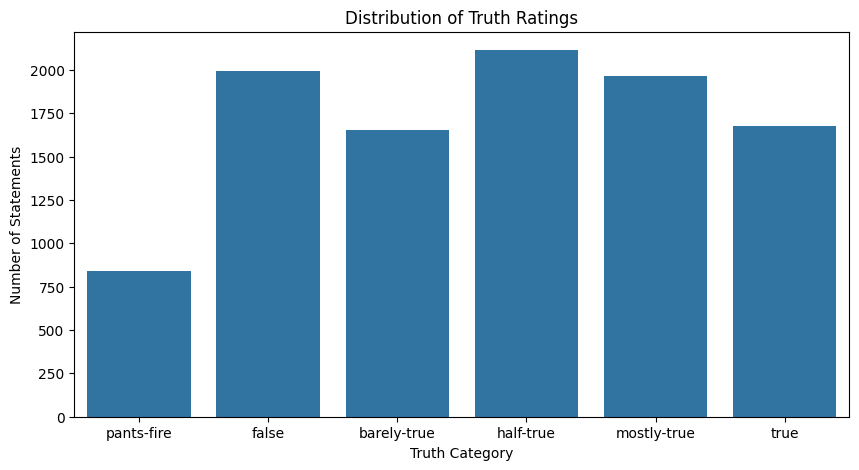

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for the 'label' column
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true'])
plt.title('Distribution of Truth Ratings')
plt.xlabel('Truth Category')
plt.ylabel('Number of Statements')
plt.show()

The visualization shows that the dataset is fairly balanced, although "pants-on-fire" statements are significantly fewer than other categories. This is an important finding because the model might have less "experience" identifying the most extreme lies compared to moderate ones.

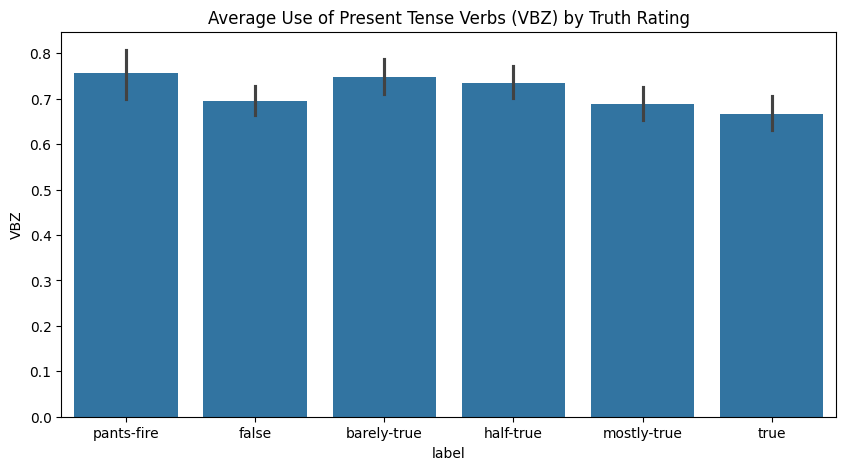

In [5]:
# Let's compare the average count of 'VBZ' (Third-person singular verbs) by truth label
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='label', y='VBZ', order=['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true'])
plt.title('Average Use of Present Tense Verbs (VBZ) by Truth Rating')
plt.show()

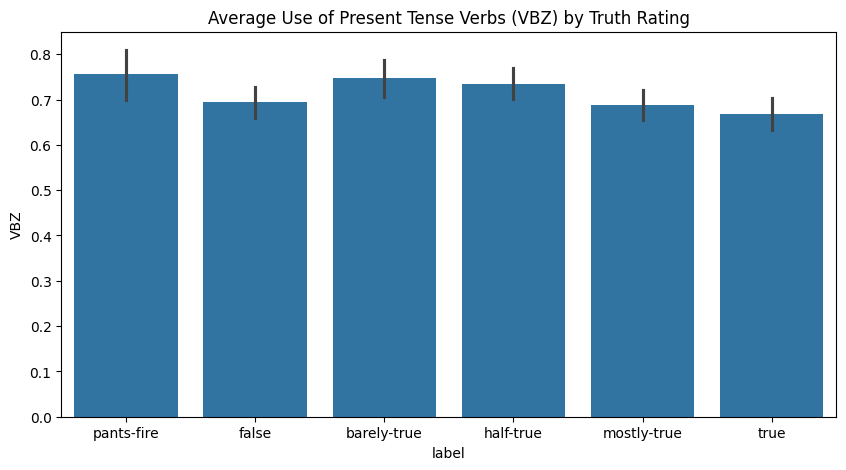

In [6]:
# Let's compare the average count of 'VBZ' (Third-person singular verbs) by truth label
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='label', y='VBZ', order=['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true'])
plt.title('Average Use of Present Tense Verbs (VBZ) by Truth Rating')
plt.show()

In [7]:
# Check basic statistics of your grammar features
print(df.describe())

         index             $       ''        (        )        ,       --  \
count  10240.0  10240.000000  10240.0  10240.0  10240.0  10240.0  10240.0   
mean       0.0      0.000684      0.0      0.0      0.0      0.0      0.0   
std        0.0      0.026138      0.0      0.0      0.0      0.0      0.0   
min        0.0      0.000000      0.0      0.0      0.0      0.0      0.0   
25%        0.0      0.000000      0.0      0.0      0.0      0.0      0.0   
50%        0.0      0.000000      0.0      0.0      0.0      0.0      0.0   
75%        0.0      0.000000      0.0      0.0      0.0      0.0      0.0   
max        0.0      1.000000      0.0      0.0      0.0      0.0      0.0   

             .        :            CC  ...           VBD           VBG  \
count  10240.0  10240.0  10240.000000  ...  10240.000000  10240.000000   
mean       0.0      0.0      0.351074  ...      0.649316      0.325098   
std        0.0      0.0      0.620238  ...      0.936800      0.602332   
min       

 I dropped the 'index' column because it is just a row identifier and carries no predictive value. I also dropped several punctuation columns (like '$', ':', and '.') because the statistical analysis showed their mean was near zero, meaning they are too rare to help the model distinguish between real and fake news.

I am saving the data as a CSV so that in future phases, I can load the "ready-to-use" data immediately without repeating the visualization and cleaning code.

In [10]:
# 1. Identify columns that are mostly empty (irrelevant)
# We will keep 'label' and 'index', but drop grammar tags that appear in less than 50 rows
limit = 50
cols_to_keep = [col for col in df.columns if (df[col] != 0).sum() > limit]

# 2. Create the cleaned dataframe
df_cleaned = df[cols_to_keep]

print(f"Original columns: {len(df.columns)}")
print(f"Columns after dropping irrelevant ones: {len(df_cleaned.columns)}")
print(df_cleaned.head())

Original columns: 47
Columns after dropping irrelevant ones: 31
   CC  CD  DT  EX  IN  JJ  JJR  JJS  MD  NN  ...  VB  VBD  VBG  VBN  VBP  VBZ  \
0   0   0   1   0   1   2    0    0   0   3  ...   0    0    0    0    0    2   
1   0   0   1   0   3   1    0    0   0   5  ...   1    4    0    0    0    0   
2   0   0   2   0   4   0    0    0   0   2  ...   1    0    1    0    0    1   
3   0   0   0   0   0   2    0    0   0   5  ...   1    0    0    0    0    1   
4   0   0   2   0   2   1    0    0   0   3  ...   0    1    0    0    0    0   

   WDT  WP  WRB        label  
0    0   0    0        false  
1    0   0    2    half-true  
2    0   0    0  mostly-true  
3    0   0    0        false  
4    0   0    0    half-true  

[5 rows x 31 columns]


In [11]:
# Save the preprocessed data to use in Phase 3
df_cleaned.to_csv('preprocessed_liar_data.csv', index=False)

print("Success! 'df_cleaned' has been saved as a CSV for the next phase.")

Success! 'df_cleaned' has been saved as a CSV for the next phase.


I identified and dropped "irrelevant features" that had very few non-zero values (less than 50 occurrences). These features do not provide enough information for the model to learn a pattern and would only add "noise" to our data.